# Bellman Equations Programming Assignment

## Applied Machine Intelligence

### Objective

This notebook demonstrates the implementation and interpretation of the Bellman expectation equation and Bellman optimality equation for a small Markov Decision Process (MDP).

The notebook will:

- define a simple MDP using states, actions, transition probabilities, rewards, and a discount factor;
- evaluate a fixed policy using the Bellman expectation equation;
- calculate the state-value function \(V^\pi(s)\);
- calculate the action-value function \(Q^\pi(s,a)\);
- find the optimal state-value function \(V^*(s)\) using the Bellman optimality equation;
- calculate the optimal action-value function \(Q^*(s,a)\);
- identify the optimal policy;
- compare values across iterations;
- demonstrate how changes in policies and rewards affect the computed values.

## Key Bellman Relationship

The central idea used throughout this notebook is:

\[
\text{Current Value}
=
\text{Immediate Reward}
+
\text{Discounted Future Value}
\]

For a fixed policy, the Bellman expectation equation evaluates the expected return under that policy.

For optimal behavior, the Bellman optimality equation compares all available actions and selects the action with the highest expected return.

In [1]:
# Import the libraries used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Improve the readability of numerical output
np.set_printoptions(precision=4, suppress=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Define the states in the Markov Decision Process
states = ["S0", "S1", "S2"]

# Define the actions available to the agent
actions = ["A0", "A1"]

# Number of states and actions
num_states = len(states)
num_actions = len(actions)

# Discount factor: determines how much future rewards matter
gamma = 0.9

print("States:", states)
print("Actions:", actions)
print("Number of states:", num_states)
print("Number of actions:", num_actions)
print("Discount factor (gamma):", gamma)

States: ['S0', 'S1', 'S2']
Actions: ['A0', 'A1']
Number of states: 3
Number of actions: 2
Discount factor (gamma): 0.9


In [3]:
# Create dictionaries that map state and action names to numerical indexes
state_to_index = {state: index for index, state in enumerate(states)}
action_to_index = {action: index for index, action in enumerate(actions)}

# Transition probability array:
# P[s, a, s_next] represents the probability of reaching s_next
# after taking action a in state s.
P = np.zeros((num_states, num_actions, num_states))

# Reward array:
# R[s, a, s_next] represents the immediate reward received
# when action a moves the agent from state s to state s_next.
R = np.zeros((num_states, num_actions, num_states))

# S0, A0 -> S1 with probability 1.0 and reward 5
P[state_to_index["S0"], action_to_index["A0"], state_to_index["S1"]] = 1.0
R[state_to_index["S0"], action_to_index["A0"], state_to_index["S1"]] = 5.0

# S0, A1 -> S2 with probability 1.0 and reward 2
P[state_to_index["S0"], action_to_index["A1"], state_to_index["S2"]] = 1.0
R[state_to_index["S0"], action_to_index["A1"], state_to_index["S2"]] = 2.0

# S1, A0 -> S2 with probability 1.0 and reward 4
P[state_to_index["S1"], action_to_index["A0"], state_to_index["S2"]] = 1.0
R[state_to_index["S1"], action_to_index["A0"], state_to_index["S2"]] = 4.0

# S1, A1 -> S0 with probability 1.0 and reward 1
P[state_to_index["S1"], action_to_index["A1"], state_to_index["S0"]] = 1.0
R[state_to_index["S1"], action_to_index["A1"], state_to_index["S0"]] = 1.0

# S2 is the terminal state.
# Both actions keep the agent in S2 with reward 0.
P[state_to_index["S2"], action_to_index["A0"], state_to_index["S2"]] = 1.0
P[state_to_index["S2"], action_to_index["A1"], state_to_index["S2"]] = 1.0

print("Transition probability array shape:", P.shape)
print("Reward array shape:", R.shape)

Transition probability array shape: (3, 2, 3)
Reward array shape: (3, 2, 3)


In [4]:
# Create a readable table showing every valid transition in the MDP
transition_rows = []

for state_index, state in enumerate(states):
    for action_index, action in enumerate(actions):
        for next_state_index, next_state in enumerate(states):
            probability = P[state_index, action_index, next_state_index]

            # Include only transitions with a nonzero probability
            if probability > 0:
                reward = R[state_index, action_index, next_state_index]

                transition_rows.append({
                    "Current State": state,
                    "Action": action,
                    "Next State": next_state,
                    "Probability": probability,
                    "Reward": reward
                })

# Convert the collected transitions into a Pandas DataFrame
transition_df = pd.DataFrame(transition_rows)

# Display the transition and reward table
transition_df

,Current State,Action,Next State,Probability,Reward
0,S0,A0,S1,1.0,5.0
1,S0,A1,S2,1.0,2.0
2,S1,A0,S2,1.0,4.0
3,S1,A1,S0,1.0,1.0
4,S2,A0,S2,1.0,0.0
5,S2,A1,S2,1.0,0.0


In [5]:
# Define a fixed policy pi(a | s)
#
# Each row represents a state.
# Each column represents an action.
#
# The values in each row are the probabilities of selecting each action.

policy = np.array([
    [1.0, 0.0],  # In S0, always choose A0
    [0.0, 1.0],  # In S1, always choose A1
    [0.5, 0.5]   # In terminal state S2, both actions are equivalent
])

# Convert the policy array into a readable table
policy_df = pd.DataFrame(
    policy,
    index=states,
    columns=actions
)

print("Fixed policy pi(a | s):")
policy_df

Fixed policy pi(a | s):


,A0,A1
S0,1.0,0.0
S1,0.0,1.0
S2,0.5,0.5


In [6]:
# Check that the action probabilities for each state add up to 1
policy_row_sums = policy.sum(axis=1)

# Create a readable validation table
policy_validation_df = pd.DataFrame({
    "State": states,
    "Probability Sum": policy_row_sums,
    "Valid Policy Row": np.isclose(policy_row_sums, 1.0)
})

policy_validation_df

,State,Probability Sum,Valid Policy Row
0,S0,1.0,True
1,S1,1.0,True
2,S2,1.0,True


In [7]:
# Start with an initial state-value function of zero for every state
V_initial = np.zeros(num_states)

# Create an empty array for the updated state values
V_after_one_update = np.zeros(num_states)

# Perform one Bellman expectation update for each state
for state_index in range(num_states):
    state_value = 0.0

    for action_index in range(num_actions):
        action_value = 0.0

        for next_state_index in range(num_states):
            transition_probability = P[
                state_index,
                action_index,
                next_state_index
            ]

            immediate_reward = R[
                state_index,
                action_index,
                next_state_index
            ]

            future_value = V_initial[next_state_index]

            action_value += transition_probability * (
                immediate_reward + gamma * future_value
            )

        state_value += policy[state_index, action_index] * action_value

    V_after_one_update[state_index] = state_value

# Display the initial and updated values
one_update_df = pd.DataFrame({
    "State": states,
    "Initial Value V0": V_initial,
    "Value After One Update V1": V_after_one_update
})

one_update_df

,State,Initial Value V0,Value After One Update V1
0,S0,0.0,5.0
1,S1,0.0,1.0
2,S2,0.0,0.0


In [8]:
def bellman_expectation_update(V, policy, P, R, gamma):
    """
    Perform one Bellman expectation update.

    Parameters
    ----------
    V : np.ndarray
        Current state-value estimates.

    policy : np.ndarray
        Policy probabilities pi(a | s).

    P : np.ndarray
        Transition probabilities P(s' | s, a).

    R : np.ndarray
        Immediate rewards R(s, a, s').

    gamma : float
        Discount factor.

    Returns
    -------
    np.ndarray
        Updated state-value estimates.
    """

    # Create a new array so the current iteration values are not overwritten
    V_new = np.zeros_like(V, dtype=float)

    # Evaluate every state
    for state_index in range(num_states):
        state_value = 0.0

        # Evaluate every action available in the state
        for action_index in range(num_actions):
            action_value = 0.0

            # Consider every possible next state
            for next_state_index in range(num_states):
                transition_probability = P[
                    state_index,
                    action_index,
                    next_state_index
                ]

                immediate_reward = R[
                    state_index,
                    action_index,
                    next_state_index
                ]

                next_state_value = V[next_state_index]

                action_value += transition_probability * (
                    immediate_reward
                    + gamma * next_state_value
                )

            # Weight the action value by the policy probability
            state_value += (
                policy[state_index, action_index]
                * action_value
            )

        V_new[state_index] = state_value

    return V_new

In [9]:
# Start again with zero values for all states
V = np.zeros(num_states)

# Store the value estimates from each iteration
expectation_history = [V.copy()]

# Perform the first three Bellman expectation updates
for iteration in range(3):
    V = bellman_expectation_update(
        V=V,
        policy=policy,
        P=P,
        R=R,
        gamma=gamma
    )

    expectation_history.append(V.copy())

# Convert the iteration history into a readable table
expectation_history_df = pd.DataFrame(
    expectation_history,
    columns=states
)

expectation_history_df.index.name = "Iteration"

expectation_history_df

,S0,S1,S2
Iteration,,,
0,0.00,0.00,0.0
1,5.00,1.00,0.0
2,5.90,5.50,0.0
3,9.95,6.31,0.0


In [10]:
# Initialize the state-value function
V_policy = np.zeros(num_states)

# Convergence settings
tolerance = 1e-8
max_iterations = 1000

# Store values from each iteration
policy_evaluation_history = [V_policy.copy()]

for iteration in range(max_iterations):
    # Perform one Bellman expectation update
    V_new = bellman_expectation_update(
        V=V_policy,
        policy=policy,
        P=P,
        R=R,
        gamma=gamma
    )

    # Measure the largest change across all states
    delta = np.max(np.abs(V_new - V_policy))

    # Save the updated values
    policy_evaluation_history.append(V_new.copy())

    # Replace the old values with the new values
    V_policy = V_new

    # Stop when the values change by less than the tolerance
    if delta < tolerance:
        break

print("Policy evaluation converged.")
print("Number of iterations:", iteration + 1)
print("Final maximum change:", delta)
print("Converged state values:", V_policy)

Policy evaluation converged.
Number of iterations: 192
Final maximum change: 9.105193043978943e-09
Converged state values: [31.0526 28.9474  0.    ]


In [11]:
# Create a readable table for the converged state-value function
state_value_policy_df = pd.DataFrame({
    "State": states,
    "V_pi(s)": V_policy
})

# Round values for easier interpretation
state_value_policy_df["V_pi(s)"] = (
    state_value_policy_df["V_pi(s)"].round(4)
)

print("State-value function under the fixed policy:")
state_value_policy_df

State-value function under the fixed policy:


,State,V_pi(s)
0,S0,31.0526
1,S1,28.9474
2,S2,0.0000


In [12]:
# Create an empty Q-value table:
# rows = states, columns = actions
Q_policy = np.zeros((num_states, num_actions))

# Calculate Q^pi(s, a) for every state-action pair
for state_index in range(num_states):
    for action_index in range(num_actions):
        action_value = 0.0

        for next_state_index in range(num_states):
            transition_probability = P[
                state_index,
                action_index,
                next_state_index
            ]

            immediate_reward = R[
                state_index,
                action_index,
                next_state_index
            ]

            next_state_value = V_policy[next_state_index]

            action_value += transition_probability * (
                immediate_reward
                + gamma * next_state_value
            )

        Q_policy[state_index, action_index] = action_value

# Convert the Q-values into a readable table
q_policy_df = pd.DataFrame(
    Q_policy,
    index=states,
    columns=actions
)

q_policy_df = q_policy_df.round(4)

print("Action-value function under the fixed policy:")
q_policy_df

Action-value function under the fixed policy:


,A0,A1
S0,31.0526,2.0000
S1,4.0000,28.9474
S2,0.0000,0.0000


In [13]:
def bellman_optimality_update(V, P, R, gamma):
    """
    Perform one Bellman optimality update.

    Parameters
    ----------
    V : np.ndarray
        Current estimates of the optimal state values.

    P : np.ndarray
        Transition probabilities P(s' | s, a).

    R : np.ndarray
        Immediate rewards R(s, a, s').

    gamma : float
        Discount factor.

    Returns
    -------
    V_new : np.ndarray
        Updated optimal state-value estimates.

    Q_values : np.ndarray
        Action values calculated during the update.
    """

    # Store the updated optimal value for each state
    V_new = np.zeros_like(V, dtype=float)

    # Store the value of every state-action pair
    Q_values = np.zeros((num_states, num_actions))

    # Evaluate every state
    for state_index in range(num_states):

        # Evaluate every action available in the current state
        for action_index in range(num_actions):
            action_value = 0.0

            # Consider all possible next states
            for next_state_index in range(num_states):
                transition_probability = P[
                    state_index,
                    action_index,
                    next_state_index
                ]

                immediate_reward = R[
                    state_index,
                    action_index,
                    next_state_index
                ]

                next_state_value = V[next_state_index]

                action_value += transition_probability * (
                    immediate_reward
                    + gamma * next_state_value
                )

            Q_values[state_index, action_index] = action_value

        # Bellman optimality: select the action with the highest value
        V_new[state_index] = np.max(Q_values[state_index])

    return V_new, Q_values

In [14]:
# Start with zero values for every state
V_optimal_initial = np.zeros(num_states)

# Perform one Bellman optimality update
V_optimal_after_one, Q_optimal_after_one = bellman_optimality_update(
    V=V_optimal_initial,
    P=P,
    R=R,
    gamma=gamma
)

# Display the Q-values from the first optimality update
q_optimal_one_df = pd.DataFrame(
    Q_optimal_after_one,
    index=states,
    columns=actions
)

# Display the updated optimal state values
v_optimal_one_df = pd.DataFrame({
    "State": states,
    "Initial Value V0": V_optimal_initial,
    "Optimal Value After One Update V1": V_optimal_after_one
})

print("Action values after the first Bellman optimality update:")
display(q_optimal_one_df)

print("Optimal state values after the first update:")
display(v_optimal_one_df)

Action values after the first Bellman optimality update:


,A0,A1
S0,5.0,2.0
S1,4.0,1.0
S2,0.0,0.0


Optimal state values after the first update:


,State,Initial Value V0,Optimal Value After One Update V1
0,S0,0.0,5.0
1,S1,0.0,4.0
2,S2,0.0,0.0


In [15]:
# Start with zero optimal state values
V_optimal = np.zeros(num_states)

# Store the state values from each iteration
optimality_history = [V_optimal.copy()]

# Store the action values from each iteration
optimality_q_history = []

# Perform three Bellman optimality updates
for iteration in range(3):
    V_optimal, Q_iteration = bellman_optimality_update(
        V=V_optimal,
        P=P,
        R=R,
        gamma=gamma
    )

    optimality_history.append(V_optimal.copy())
    optimality_q_history.append(Q_iteration.copy())

# Convert the state-value history into a readable table
optimality_history_df = pd.DataFrame(
    optimality_history,
    columns=states
)

optimality_history_df.index.name = "Iteration"

optimality_history_df

,S0,S1,S2
Iteration,,,
0,0.00,0.00,0.0
1,5.00,4.00,0.0
2,8.60,5.50,0.0
3,9.95,8.74,0.0


In [16]:
# Initialize the optimal state-value function
V_optimal = np.zeros(num_states)

# Convergence settings
tolerance = 1e-8
max_iterations = 1000

# Store value estimates from every iteration
value_iteration_history = [V_optimal.copy()]

for iteration in range(max_iterations):
    # Perform one Bellman optimality update
    V_new, Q_new = bellman_optimality_update(
        V=V_optimal,
        P=P,
        R=R,
        gamma=gamma
    )

    # Measure the largest change across all state values
    delta = np.max(np.abs(V_new - V_optimal))

    # Save the new values
    value_iteration_history.append(V_new.copy())

    # Update the current values
    V_optimal = V_new

    # Stop when the values have converged
    if delta < tolerance:
        break

print("Value iteration converged.")
print("Number of iterations:", iteration + 1)
print("Final maximum change:", delta)
print("Optimal state values:", V_optimal)

Value iteration converged.
Number of iterations: 189
Final maximum change: 9.991985905344336e-09
Optimal state values: [31.0526 28.9474  0.    ]


In [18]:
# Recalculate the Q-values using the converged optimal state values
V_check, Q_optimal = bellman_optimality_update(
    V=V_optimal,
    P=P,
    R=R,
    gamma=gamma
)

# Convert the optimal Q-values into a readable table
q_optimal_df = pd.DataFrame(
    Q_optimal,
    index=states,
    columns=actions
)

q_optimal_df = q_optimal_df.round(4)

print("Optimal action-value function Q*(s, a):")
q_optimal_df

Optimal action-value function Q*(s, a):


,A0,A1
S0,31.0526,2.0000
S1,4.0000,28.9474
S2,0.0000,0.0000


In [19]:
# Select the action with the highest optimal Q-value in each state
optimal_action_indices = np.argmax(Q_optimal, axis=1)

# Convert numerical action indexes back to action names
optimal_actions = [
    actions[action_index]
    for action_index in optimal_action_indices
]

# Create a readable optimal-policy table
optimal_policy_df = pd.DataFrame({
    "State": states,
    "Optimal Action": optimal_actions,
    "Optimal State Value V*(s)": V_optimal
})

optimal_policy_df["Optimal State Value V*(s)"] = (
    optimal_policy_df["Optimal State Value V*(s)"].round(4)
)

print("Optimal policy derived from Q*(s, a):")
optimal_policy_df

Optimal policy derived from Q*(s, a):


,State,Optimal Action,Optimal State Value V*(s)
0,S0,A0,31.0526
1,S1,A1,28.9474
2,S2,A0,0.0000


In [20]:
# Compare the fixed-policy values with the optimal values
value_comparison_df = pd.DataFrame({
    "State": states,
    "V_pi(s)": V_policy,
    "V_star(s)": V_optimal,
    "Difference": V_optimal - V_policy
})

# Round the values for readability
value_comparison_df = value_comparison_df.round(4)

print("Comparison of fixed-policy and optimal state values:")
value_comparison_df

Comparison of fixed-policy and optimal state values:


,State,V_pi(s),V_star(s),Difference
0,S0,31.0526,31.0526,-0.0
1,S1,28.9474,28.9474,-0.0
2,S2,0.0000,0.0000,0.0


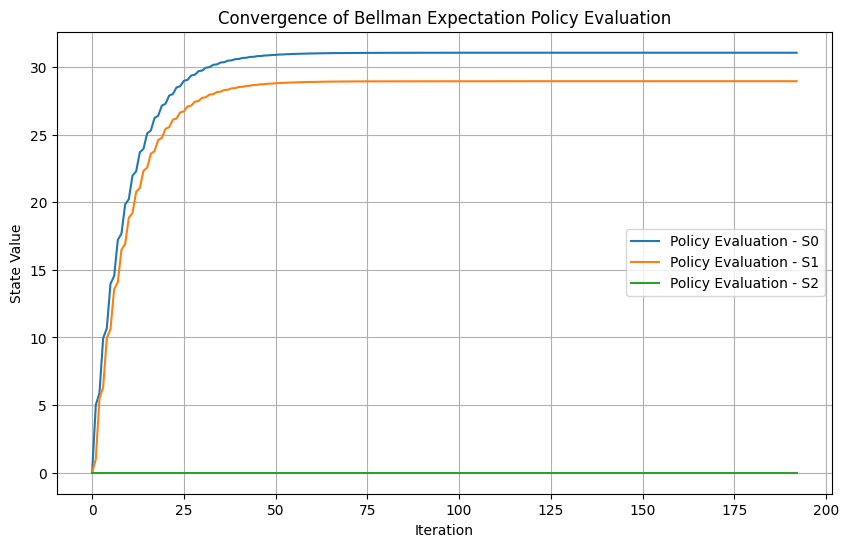

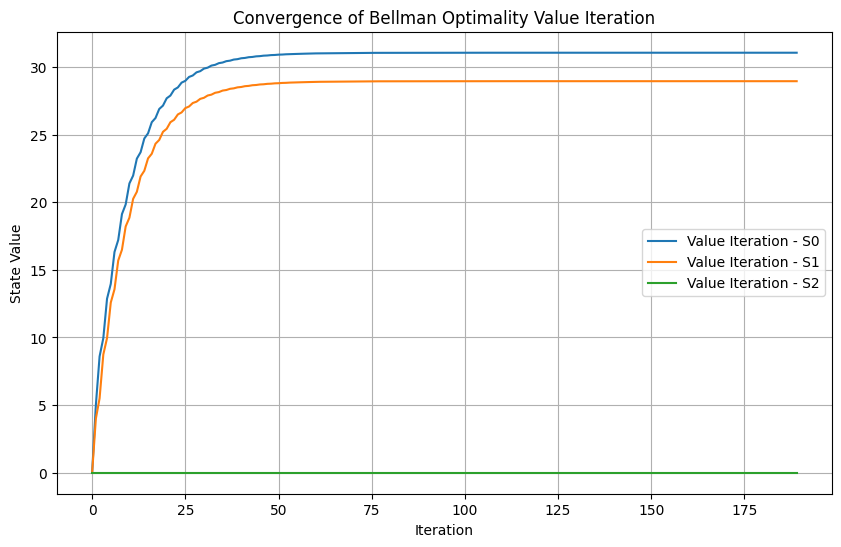

In [21]:
# Convert the stored histories into NumPy arrays
policy_history_array = np.array(policy_evaluation_history)
value_history_array = np.array(value_iteration_history)

# Plot policy evaluation convergence
plt.figure(figsize=(10, 6))

for state_index, state in enumerate(states):
    plt.plot(
        policy_history_array[:, state_index],
        label=f"Policy Evaluation - {state}"
    )

plt.xlabel("Iteration")
plt.ylabel("State Value")
plt.title("Convergence of Bellman Expectation Policy Evaluation")
plt.legend()
plt.grid(True)
plt.show()

# Plot value iteration convergence
plt.figure(figsize=(10, 6))

for state_index, state in enumerate(states):
    plt.plot(
        value_history_array[:, state_index],
        label=f"Value Iteration - {state}"
    )

plt.xlabel("Iteration")
plt.ylabel("State Value")
plt.title("Convergence of Bellman Optimality Value Iteration")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
# Create a copy of the original reward array
R_modified = R.copy()

# Increase the reward for:
# S0 --A0--> S1
# from 5 to 8
R_modified[
    state_to_index["S0"],
    action_to_index["A0"],
    state_to_index["S1"]
] = 8.0

# Initialize state values for the modified MDP
V_modified = np.zeros(num_states)

# Store convergence history for the modified reward experiment
modified_value_history = [V_modified.copy()]

# Run value iteration using the modified reward array
for iteration in range(max_iterations):
    V_new_modified, Q_new_modified = bellman_optimality_update(
        V=V_modified,
        P=P,
        R=R_modified,
        gamma=gamma
    )

    delta_modified = np.max(
        np.abs(V_new_modified - V_modified)
    )

    modified_value_history.append(
        V_new_modified.copy()
    )

    V_modified = V_new_modified

    if delta_modified < tolerance:
        break

# Calculate final Q-values using the converged modified values
V_modified_check, Q_modified = bellman_optimality_update(
    V=V_modified,
    P=P,
    R=R_modified,
    gamma=gamma
)

# Identify the optimal action in each state
modified_optimal_action_indices = np.argmax(
    Q_modified,
    axis=1
)

modified_optimal_actions = [
    actions[action_index]
    for action_index in modified_optimal_action_indices
]

# Compare original and modified results
reward_change_comparison_df = pd.DataFrame({
    "State": states,
    "Original V*(s)": V_optimal,
    "Modified V*(s)": V_modified,
    "Value Change": V_modified - V_optimal,
    "Original Optimal Action": optimal_actions,
    "Modified Optimal Action": modified_optimal_actions
})

reward_change_comparison_df = (
    reward_change_comparison_df.round(4)
)

print("Effect of increasing the S0-A0 reward from 5 to 8:")
print("Modified value iteration iterations:", iteration + 1)

reward_change_comparison_df

Effect of increasing the S0-A0 reward from 5 to 8:
Modified value iteration iterations: 191


,State,Original V*(s),Modified V*(s),Value Change,Original Optimal Action,Modified Optimal Action
0,S0,31.0526,46.8421,15.7895,A0,A0
1,S1,28.9474,43.1579,14.2105,A1,A1
2,S2,0.0000,0.0000,0.0000,A0,A0


In [23]:
# Check whether the converged state values satisfy
# the Bellman expectation and optimality relationships

# One additional Bellman expectation update
V_policy_check = bellman_expectation_update(
    V=V_policy,
    policy=policy,
    P=P,
    R=R,
    gamma=gamma
)

# One additional Bellman optimality update
V_optimal_check, Q_optimal_check = bellman_optimality_update(
    V=V_optimal,
    P=P,
    R=R,
    gamma=gamma
)

# Compare V*(s) with the maximum Q*(s, a) in each state
max_q_optimal = np.max(Q_optimal_check, axis=1)

# Create a validation table
bellman_validation_df = pd.DataFrame({
    "State": states,
    "V_pi(s)": V_policy,
    "Expectation Update": V_policy_check,
    "V_star(s)": V_optimal,
    "Maximum Q_star(s,a)": max_q_optimal,
    "Expectation Consistent": np.isclose(
        V_policy,
        V_policy_check,
        atol=tolerance
    ),
    "Optimality Consistent": np.isclose(
        V_optimal,
        max_q_optimal,
        atol=tolerance
    )
})

bellman_validation_df = bellman_validation_df.round(6)

print("Bellman equation validation:")
bellman_validation_df

Bellman equation validation:


,State,V_pi(s),Expectation Update,V_star(s),"Maximum Q_star(s,a)",Expectation Consistent,Optimality Consistent
0,S0,31.052632,31.052632,31.052632,31.052632,True,True
1,S1,28.947368,28.947368,28.947368,28.947368,True,True
2,S2,0.000000,0.000000,0.000000,0.000000,True,True


## Results and Interpretation

This notebook implemented both the Bellman expectation equation and the Bellman optimality equation for a small Markov Decision Process.

### Bellman Expectation Results

The fixed policy selected:

- \(A0\) in \(S0\)
- \(A1\) in \(S1\)

Iterative policy evaluation converged to:

\[
V^\pi(S0) = 31.0526
\]

\[
V^\pi(S1) = 28.9474
\]

\[
V^\pi(S2) = 0
\]

The corresponding action-value function was:

| State | \(Q^\pi(s,A0)\) | \(Q^\pi(s,A1)\) |
|---|---:|---:|
| \(S0\) | 31.0526 | 2.0000 |
| \(S1\) | 4.0000 | 28.9474 |
| \(S2\) | 0.0000 | 0.0000 |

These results show that the value of a state includes both the immediate reward and the discounted value of future states.

### Bellman Optimality Results

Value iteration produced the optimal state values:

\[
V^*(S0) = 31.0526
\]

\[
V^*(S1) = 28.9474
\]

\[
V^*(S2) = 0
\]

The optimal policy was:

- \(S0 \rightarrow A0\)
- \(S1 \rightarrow A1\)

The fixed policy and optimal policy produced the same values. Therefore, the original fixed policy was already optimal for this MDP.

### Reward Modification Experiment

The reward for the transition from \(S0\) to \(S1\) using \(A0\) was increased from 5 to 8.

The modified optimal values became:

\[
V^*(S0) = 46.8421
\]

\[
V^*(S1) = 43.1579
\]

The optimal actions did not change, but the values of both connected states increased. This demonstrates that changing one reward can affect the long-term values of multiple states because rewards propagate backward through the MDP.

### Main Conclusion

The Bellman expectation equation evaluates the long-term value of following a specified policy. The Bellman optimality equation compares all available actions and selects the action with the highest expected return.

The central relationship demonstrated in this notebook is:

\[
\text{Current Value}
=
\text{Immediate Reward}
+
\text{Discounted Future Value}
\]

Repeated Bellman updates allow future rewards to propagate through the state space until the values converge.

## AI Use Disclosure

ChatGPT was used to help explain Bellman equations, organize the notebook, develop and review the Python implementation, and improve the clarity of the comments and interpretations. All code, calculations, and outputs were reviewed and executed by the student to verify correctness and support personal understanding of the assignment concepts.